In [1]:
import warnings

warnings.filterwarnings('ignore')
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
if torch.cuda.is_available():
    device = "cuda" 
else:
    device = "cpu" 
    
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root='/home/parisibr/Atividade-Aula-Pr-tica-MLP-CNN/dataset/versions/1/flower_photos', transform=transform)

# Tamanho total do dataset
total_size = len(dataset)

# Separação 70% treino, 15% teste e 15% validação
train_size = int(0.7 * total_size)
test_size = int(0.15 * total_size)
validation_size = total_size - train_size - test_size

# Separando o dataset
train_dataset, test_dataset, validation_dataset = random_split(
    dataset,
    [train_size, test_size, validation_size]
)

# Criando os DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)

In [3]:
print("Classes:", dataset.classes)

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [4]:
import matplotlib.pyplot as plt

def show_batch(dataloader, title="Batch of Images"):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            ax.imshow(img)
            ax.set_title(dataset.classes[labels[i]])
            ax.axis('off')
    plt.show()

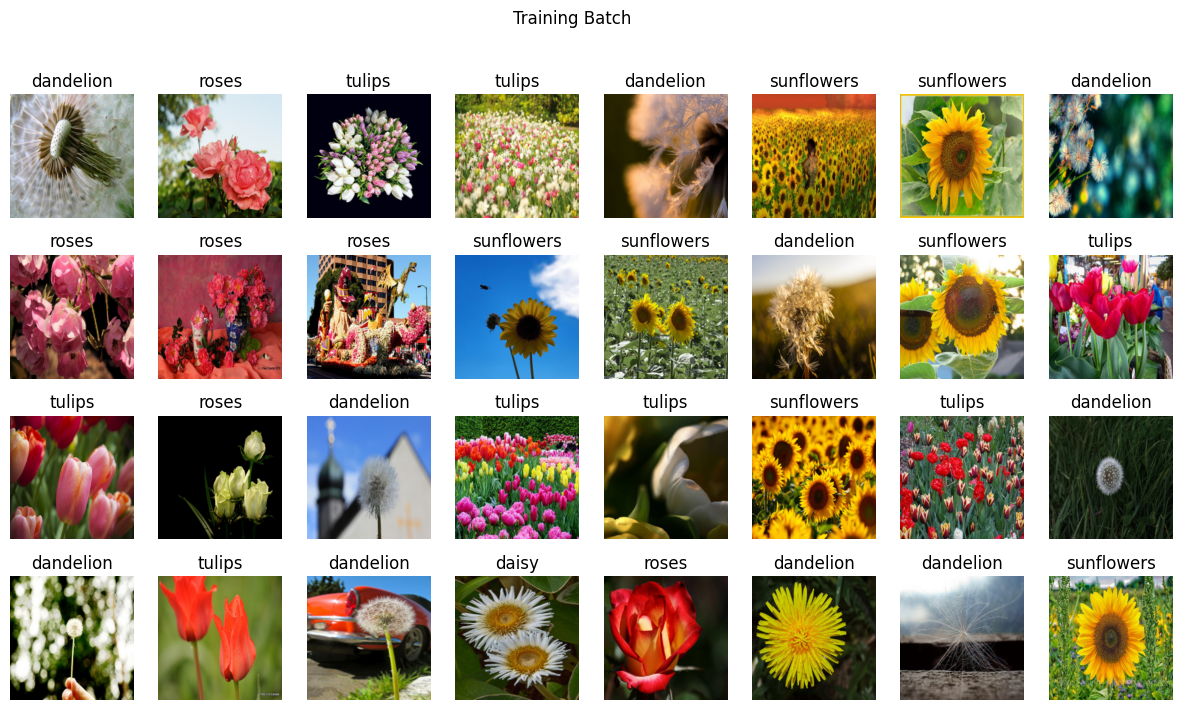

In [5]:
show_batch(train_loader, title="Training Batch")

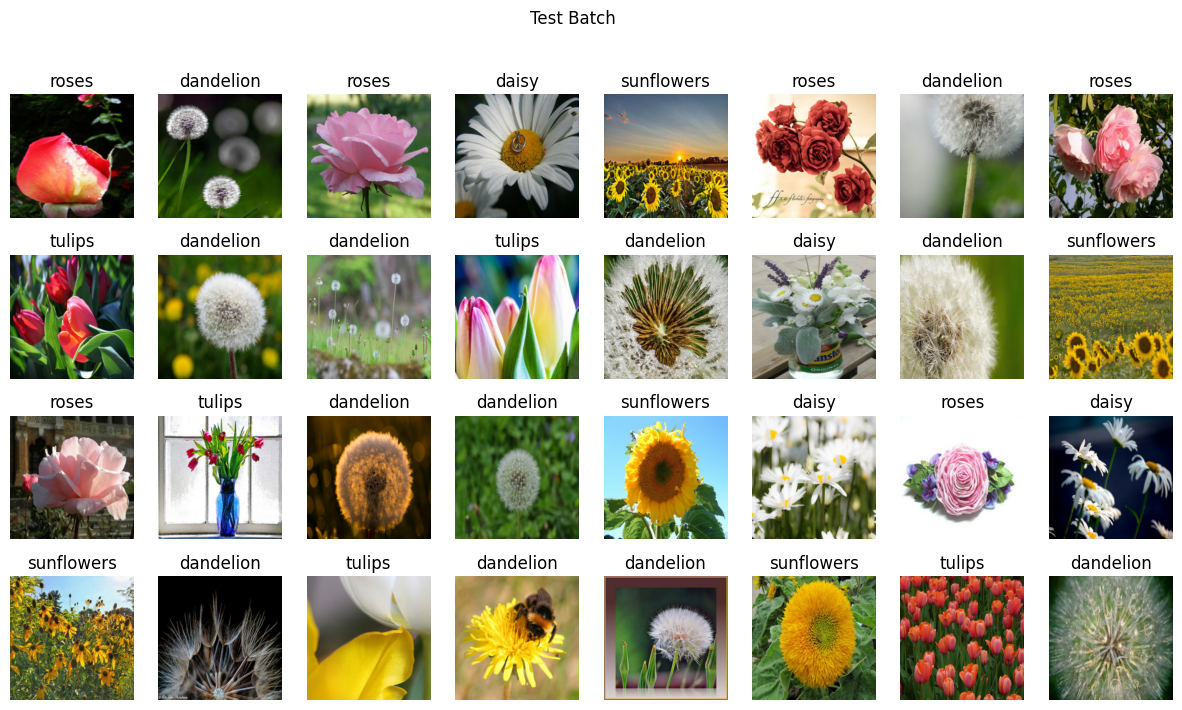

In [6]:
show_batch(test_loader, title="Test Batch")

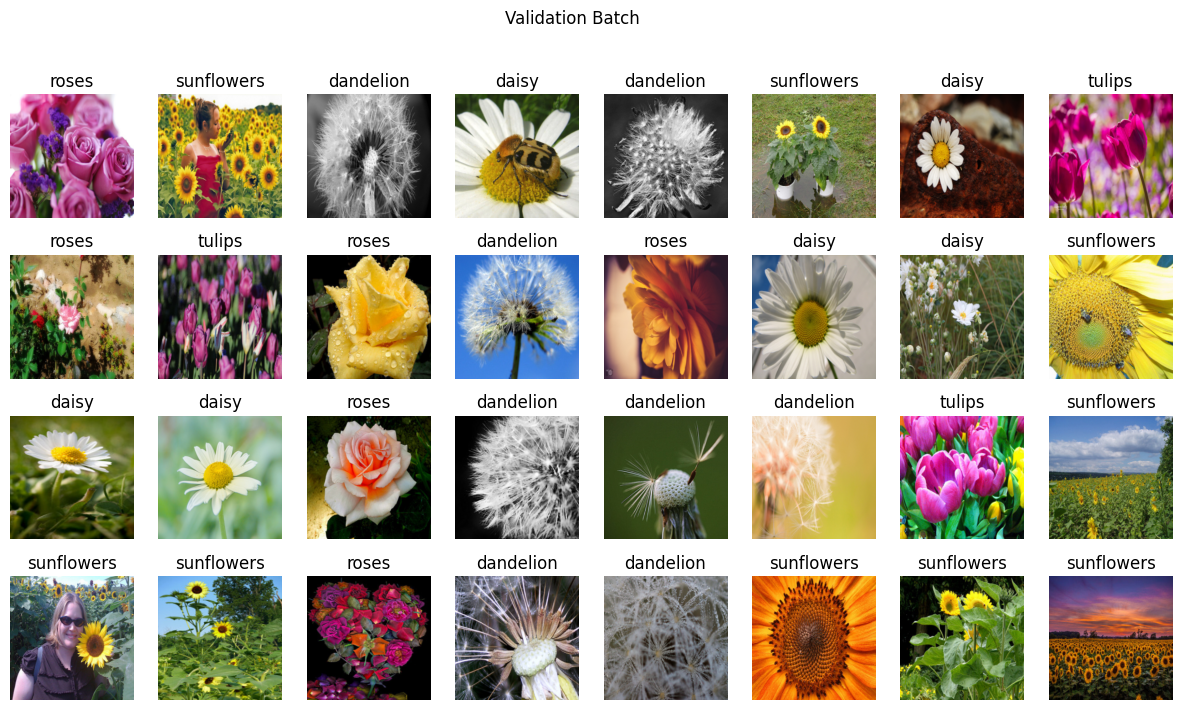

In [7]:
show_batch(validation_loader, title="Validation Batch")

In [8]:
from torch import nn, optim
from torchvision.models import resnet50, ResNet50_Weights

model=resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model=model.to(device)

In [9]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    
    with torch.inference_mode():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f},Accuracy of the model on the validation set: {100 * correct / total:.2f}")

100%|██████████| 18/18 [00:04<00:00,  4.07it/s]


Epoch [1/10], Loss: 0.5926,Accuracy of the model on the validation set: 68.55


100%|██████████| 18/18 [00:04<00:00,  3.75it/s]


Epoch [2/10], Loss: 0.3368,Accuracy of the model on the validation set: 83.27


100%|██████████| 18/18 [00:04<00:00,  3.90it/s]


...

Epoch [8/10], Loss: 0.0577,Accuracy of the model on the validation set: 86.18


100%|██████████| 18/18 [00:04<00:00,  3.90it/s]


Epoch [9/10], Loss: 0.0949,Accuracy of the model on the validation set: 81.27


100%|██████████| 18/18 [00:03<00:00,  4.61it/s]

Epoch [10/10], Loss: 0.0810,Accuracy of the model on the validation set: 87.64


In [10]:
torch.save(model.state_dict(), 'flower_classification.pth')

In [11]:
import torch
from torch import nn
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image

# Usar GPU se disponível
device = "cuda" if torch.cuda.is_available() else "cpu"

# Classes na mesma ordem do ImageFolder
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# Recriar a mesma arquitetura usada no treino
model = resnet50(weights=None)

# Alterar a última camada para 5 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Carregar os pesos treinados
model.load_state_dict(
    torch.load("flower_classification.pth", map_location=device)
)

# Enviar para CPU/GPU
model = model.to(device)

# Colocar em modo de avaliação
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Acurácia no dataset de teste: {accuracy:.2f}%")

Acurácia no dataset de teste: 87.64%


In [13]:
for i in range(len(all_predictions)):
    real_class = class_names[all_labels[i]]
    predicted_class = class_names[all_predictions[i]]

    print(f"Real: {real_class} | Previsto: {predicted_class}")

Real: roses | Previsto: roses
Real: dandelion | Previsto: dandelion
Real: roses | Previsto: tulips
Real: daisy | Previsto: daisy
Real: sunflowers | Previsto: sunflowers
Real: roses | Previsto: roses
Real: dandelion | Previsto: dandelion
Real: roses | Previsto: roses
Real: tulips | Previsto: tulips
Real: dandelion | Previsto: dandelion
Real: dandelion | Previsto: dandelion
Real: tulips | Previsto: tulips
Real: dandelion | Previsto: dandelion
Real: daisy | Previsto: tulips
Real: dandelion | Previsto: dandelion
Real: sunflowers | Previsto: sunflowers
Real: roses | Previsto: roses
Real: tulips | Previsto: tulips
Real: dandelion | Previsto: dandelion
Real: dandelion | Previsto: dandelion
Real: sunflowers | Previsto: sunflowers
Real: daisy | Previsto: daisy
Real: roses | Previsto: roses
Real: daisy | Previsto: daisy
Real: sunflowers | Previsto: sunflowers
Real: dandelion | Previsto: dandelion
Real: tulips | Previsto: tulips
Real: dandelion | Previsto: dandelion
Real: dandelion | Previsto: da

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de confusão:")
print(confusion_matrix(all_labels, all_predictions))

print("\nRelatório de classificação:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))

Matriz de confusão:
[[ 86   6   0   2   4]
 [  3 131   1   3   2]
 [  4   3  64   3  19]
 [  0   3   0  94   2]
 [  1   1   6   5 107]]

Relatório de classificação:
              precision    recall  f1-score   support

       daisy       0.91      0.88      0.90        98
   dandelion       0.91      0.94      0.92       140
       roses       0.90      0.69      0.78        93
  sunflowers       0.88      0.95      0.91        99
      tulips       0.80      0.89      0.84       120

    accuracy                           0.88       550
   macro avg       0.88      0.87      0.87       550
weighted avg       0.88      0.88      0.87       550

